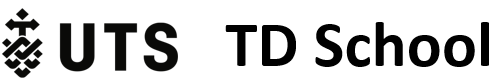



**36103 Statistical Thinking for Data Science**



 **Tutorial 3 : Logistic Regression**


In this tutorial, we will explore practical applications of logistic regression model. Logistic regression is a commonly used type of Generalized Linear Model (GLM).
# Credit Risk Tutorial — EDA, Feature Selection, and Logistic Regression (with Custom Colors)

This notebook walks through:
- Why and how to use **custom colors** for your charts (e.g., company palette, website theme).
- **Exploratory Data Analysis (EDA)** using a custom palette.
- **Feature selection** techniques for **binary classification**.
- Training a **logistic regression** model with `statsmodels` and reviewing model performance.
- Training the **same model with scikit-learn** and comparing results.

**Dataset:** `Tu3Credit_Risk_Data.csv` (binary target: `default`).

Credit risk refers to the potential of individuals being unable to repay their loans, leading to financial losses for the lender or creditor. Our analysis focuses on predicting the likelihood of customer default by leveraging a credit risk dataset. Each entry in the dataset represents a unique loan, and the "default" response variable assumes a value of one if the client failed to repay the loan and zero if the client successfully fulfilled their repayment obligations.

## 1. Importing Libraries and Setting Up the Environment
In this section, we will import the necessary libraries and set up the environment, customizing the color palette for our visualizations. This will ensure that our plots are visually appealing and consistent with our branding or personal preferences.

In [ ]:
!pip install statsmodels imbalanced-learn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, roc_auc_score,
                             precision_score, classification_report)
import statsmodels.api as sm

pd.set_option("display.max_columns", None)
plt.rcParams["axes.grid"] = False

# Custom color palette — feel free to adjust hex codes to your preference
colors = ["#4C78A8", "#F58518", "#E45756", "#72B7B2", "#54A24B", "#E2CF5B"]
binary_color = ["#4C78A8", "#A9A9A9"]

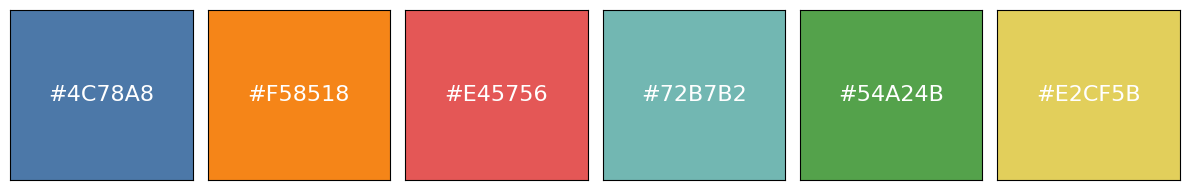

In [ ]:
def plot_colors(colors):
    n = len(colors)
    cols = 6
    rows = 1
    fig, axes = plt.subplots(rows, cols, figsize=(12, 2 * rows))
    for i, ax in enumerate(axes.flat):
        ax.set_facecolor(colors[i])
        ax.text(0.5, 0.5, colors[i], color='white', fontsize=16, ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()
    plt.show()

plot_colors(colors)


## 2. Data Loading and Initial Exploration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Reading in data
data=pd.read_csv('/content/drive/MyDrive/UTS/data/Tu3Credit_Risk_Data.csv')
data.head()

,default,duration,amount,employment,installment_rate,personal,other_debtors,residence,property,age,housing,existing_credits,foreign_worker
0,0,42,7882,A74,2,A93,A103,4,A122,45,A153,1,1
1,1,24,4870,A73,3,A93,A101,4,A124,53,A153,2,1
2,0,36,9055,A73,2,A93,A101,4,A124,35,A153,1,1
3,0,24,2835,A75,3,A93,A101,4,A122,53,A152,1,1
4,0,36,6948,A73,2,A93,A101,2,A123,35,A151,1,1


In [ ]:
# Check for duplicates
duplicates = data.duplicated().sum()
print('Number of duplicate rows:', duplicates)

Number of duplicate rows: 0


In [ ]:
# Check for missing values
data.isnull().sum()

,0
default,0
duration,0
amount,0
employment,0
installment_rate,0
personal,0
other_debtors,0
residence,0
property,0
age,0


- This dataset does not contain any missing values and duplicates. This is a good starting point for our analysis, as it ensures that we have complete data for each entry without any redundancy.

#### Create List of Variables by Type
The dataset comprises a diverse range of variables, encompassing continuous, discrete, and categorical types. These variables represent distinct aspects of the data, allowing for a comprehensive analysis of the information at hand.

We'll categorize the variables into four types: continuous, discrete, categorical, and binary. This categorization will help us understand the nature of each variable and how they can be used in our analysis.

In [ ]:
# Create a list of variables by type
continuous = ['duration', 'amount', 'age']

discrete = ['installment_rate', 'residence', 'existing_credits']

categorical = [ 'employment', 'personal',  'other_debtors', 'property', 'housing']

binary = ['foreign_worker']

response = ['default']

### Checking the Target Variable Distribution Before Splitting the Dataset
Before splitting the dataset, let's take a look at the target variable, which is the "default" variable. This variable indicates whether a borrower has defaulted on their loan (1) or not (0). Understanding the distribution of this variable is crucial for our analysis, as it will help us identify patterns and trends related to loan defaults.

In [ ]:
# Target variable distribution
data['default'].value_counts(normalize=True).round(2)

,proportion
default,
0,0.7
1,0.3


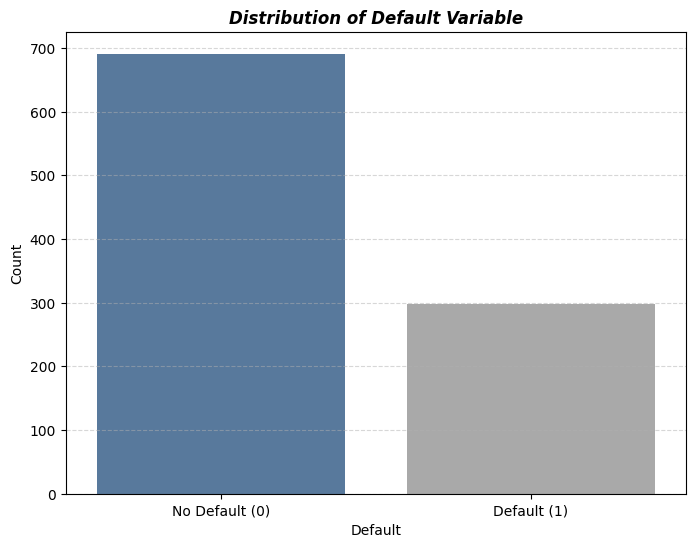

In [ ]:
# Plotting the target variable distribution using a count plot with custom colors
plt.figure(figsize=(8, 6))
sns.countplot(x="default", data=data, palette=binary_color, hue="default", legend=False)
plt.title("Distribution of Default Variable", fontweight="bold", style="italic")
plt.xlabel("Default")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["No Default (0)", "Default (1)"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

- **Default (1):** The borrower failed to repay the loan as agreed. This means they missed payments beyond an acceptable threshold, making them a high-risk borrower.
- **No Default" (0):** The borrower successfully repaid the loan on time or within an acceptable grace period, meaning they are a low-risk borrower.

Our target variable "default" is is imbalanced, with 70% of the data indicating no default (0) and 30% indicating default (1). This imbalance is important to consider when building our predictive models, as it may affect the model's performance and the interpretation of results.

## 3. Data Splitting
We split the dataset into training (80%) and validation (20%) sets using **stratified sampling**.

Stratification ensures both sets preserve the original 70/30 class ratio of the target variable "default". Without it, a random split could place a disproportionate number of defaults in one set, leading to unreliable evaluation.

In [ ]:
# Stratified split: preserves the 70/30 default ratio in both sets
index_train, index_valid = train_test_split(
    data.index,
    train_size=0.8,
    random_state=21,
    stratify=data["default"]  # ensures the same class ratio in both sets
)

train = data.loc[index_train, :].copy()
valid = data.loc[index_valid, :].copy()

In [ ]:
# Target variable distribution
train['default'].value_counts(normalize=True).round(2)

,proportion
default,
0,0.7
1,0.3


The splitting strategy ensures that both the training and validation sets maintain the same distribution of the target variable, "default". This is crucial for building a robust model when target variable is imbalanced.

## 4. Exploratory Data Analysis (EDA)

In [ ]:
# Descriptive statistics
train.describe().round(2)

,default,duration,amount,installment_rate,residence,age,existing_credits,foreign_worker
count,791.00,791.00,791.00,791.00,791.00,791.00,791.00,791.00
mean,0.30,20.56,3167.84,2.99,2.83,35.52,1.40,0.96
std,0.46,11.92,2776.90,1.11,1.10,11.30,0.57,0.19
min,0.00,4.00,250.00,1.00,1.00,19.00,1.00,0.00
25%,0.00,12.00,1344.50,2.00,2.00,27.00,1.00,1.00
50%,0.00,18.00,2255.00,3.00,3.00,33.00,1.00,1.00
75%,1.00,24.00,3842.50,4.00,4.00,42.00,2.00,1.00
max,1.00,72.00,18424.00,4.00,4.00,75.00,4.00,1.00


In [ ]:
# Data Information
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 791 entries, 34 to 959
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   default           791 non-null    int64 
 1   duration          791 non-null    int64 
 2   amount            791 non-null    int64 
 3   employment        791 non-null    object
 4   installment_rate  791 non-null    int64 
 5   personal          791 non-null    object
 6   other_debtors     791 non-null    object
 7   residence         791 non-null    int64 
 8   property          791 non-null    object
 9   age               791 non-null    int64 
 10  housing           791 non-null    object
 11  existing_credits  791 non-null    int64 
 12  foreign_worker    791 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 86.5+ KB


The code snippet below demonstrates a loop that enables the plotting of multiple continuous variables simultaneously

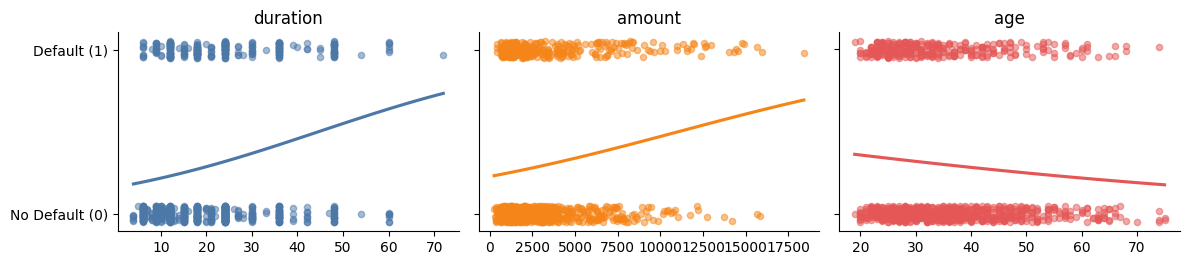

In [ ]:
# ------------------------ Data slices --------------------------
X = data[continuous]                   # Choose continuous predictors
y = data['default']                    # Binary target (0/1)
labels = X.columns.to_list()           # Feature names for subplot titles
p = X.shape[1]                         # Number of features (columns in X)

# ------------------------ Subplot grid -------------------------
n_cols = 3
n_rows = int(np.ceil(p / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.75 * n_rows))
axes = np.atleast_1d(axes).ravel()     # handles 1-row case

# ---------------- Draw one regplot per feature -----------------
for i in range(n_rows * n_cols):
    if i < p:
        ax = axes[i]
        xi = X.iloc[:, i]              # Current feature vector

        # Scatter + logistic regression curve
        sns.regplot(
            x=xi, y=y,
            ci=None,                    # No confidence interval ribbon
            logistic=True,              # Fit logistic curve (suitable for binary y)
            y_jitter=0.05,              # Jitter points vertically to show overlap
            scatter_kws={'s': 20, 'alpha': 0.5},    # Small, semi-transparent markers
            color=colors[i % len(colors)],          # Cycle through custom colors
            ax=ax
        )
        # Title only; keep axes clean
        ax.set(title=labels[i], xlabel='', ylabel='')

        # Show only 0 and 1 on y-axis; label only the leftmost column to avoid clutter
        if i % 3 == 0:                  # Left column in a 3-column grid
            ax.set_yticks([0, 1])
            ax.set_yticklabels(['No Default (0)', 'Default (1)'])
        else:
            ax.set_yticks([0, 1])
            ax.set_yticklabels([])      # Keep ticks but hide labels on other columns

    else:
        fig.delaxes(axes[i])            # Remove any unused subplot if grid has more slots than features

# ------------------------ Final polish -------------------------
sns.despine()                          # Remove top/right spines for a cleaner look
plt.tight_layout()                     # Resolve spacing between subplots
plt.show()                             # Render the figure



#### **Key takeaways from the scatter plots with logistic regression curves:**
- **duration → default:** Clear positive relationship. Longer duration is associated with a higher probability of default. Visually this is the steepest trend of the three, so duration looks like a strong predictor.

- **amount → default:** Positive relationship. Larger loan amounts correspond to higher default probability. The spread is wide and likely right-skewed, so a log transform of amount may give a cleaner fit.

- **age → default:** Negative relationship. Younger customers show a higher likelihood of default, while the probability decreases as age increases. The effect appears weaker than duration but still consistent.



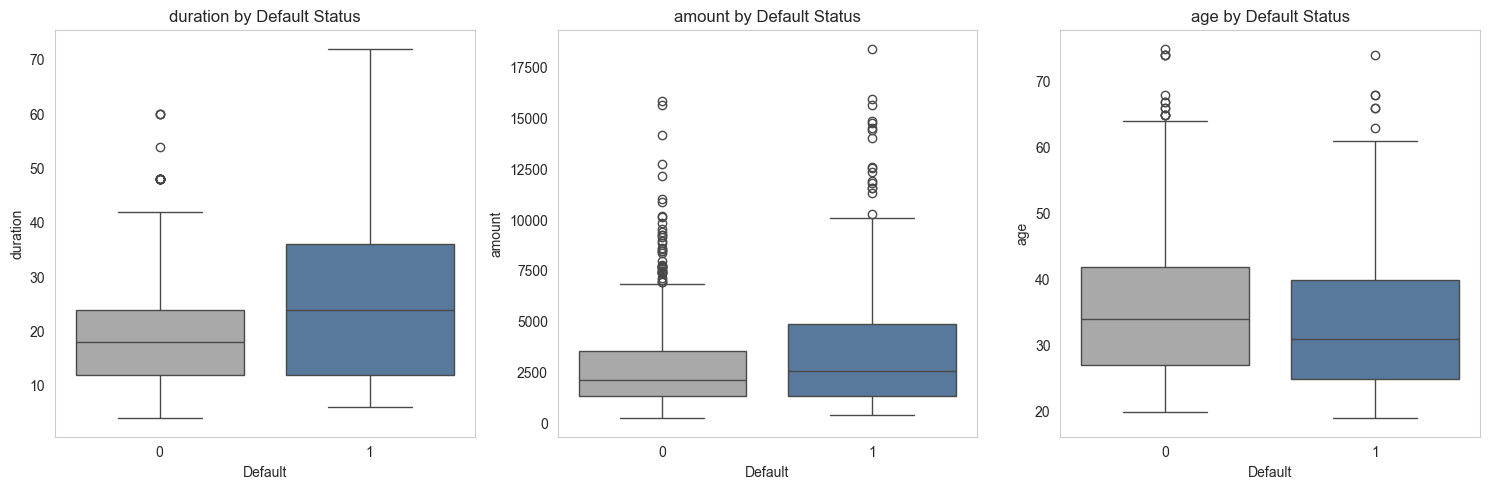

In [ ]:
# Box plots for continuous variables by default status
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, ax in enumerate(axes):
    sns.boxplot(x='default', y=continuous[i], data=train, ax=ax,
                palette={0: binary_color[1], 1: binary_color[0]}, hue='default', legend=False)
    ax.set_title(f'{continuous[i]} by Default Status')
    ax.set_xlabel('Default')
    ax.set_ylabel(continuous[i])
plt.tight_layout()
plt.show()


### Distribution by Default Status (KDE Plots)

Kernel Density Estimation (KDE) plots show the distribution of each continuous variable separately for defaulters and non-defaulters. Unlike scatter plots, KDE plots make it easy to see:
- Whether the two classes have **overlapping or well-separated distributions**, more separation means a stronger predictor.
- The **shape** of each distribution (skewness, heavy tails) which may suggest transformations are needed.

If the two KDE curves largely overlap, that variable alone has limited discriminating power.

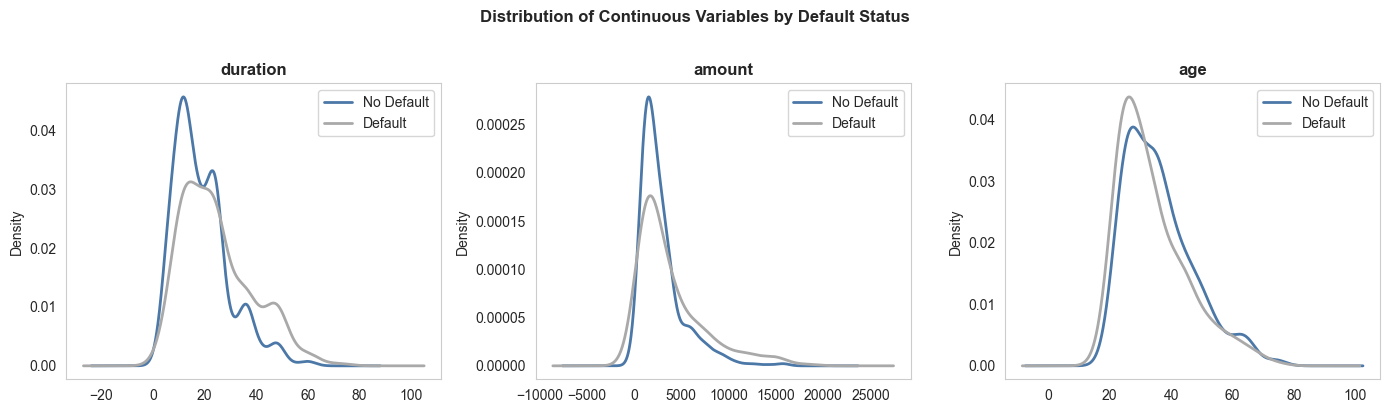

In [ ]:
fig, axes = plt.subplots(1, len(continuous), figsize=(14, 4))

for ax, var in zip(axes, continuous):
    for val, label, color in zip([0, 1], ["No Default", "Default"], binary_color):
        subset = train.loc[train["default"] == val, var]
        subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
    ax.set_title(var, fontweight="bold")
    ax.set_xlabel("")
    ax.legend()

fig.suptitle("Distribution of Continuous Variables by Default Status", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Correlation Heatmap

The correlation heatmap shows pairwise **Pearson correlations** between all continuous variables. This is a quick visual check for multicollinearity before fitting the model.

- Values close to **+1 or -1** indicate strong linear correlation — two variables are carrying similar information.
- Values close to **0** indicate little linear relationship.

If two predictors are highly correlated (|r| > 0.8), keeping both in the model inflates standard errors and makes coefficients unreliable. We will quantify this more precisely with VIF in Section 5.

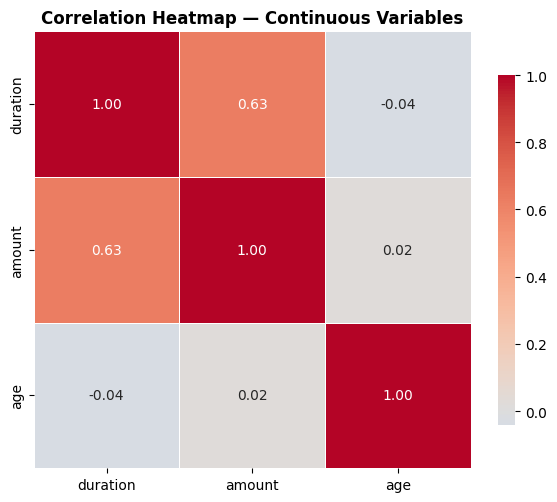

In [ ]:
corr = train[continuous].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap — Continuous Variables", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
def crosstabplots(X, y):
    labels = list(X.columns)
    N, p = X.shape
    rows = int(np.ceil(p/3))
    # colors = sns.color_palette('tab20') # Use a color palette from seaborn library
    fig, axes = plt.subplots(rows, 3, figsize=(12, rows*(12/4)))

    for i, ax in enumerate(fig.axes):
        if i < p:

            table=pd.crosstab(y, X.iloc[:,i])
            table = (table/table.sum()).iloc[1,:]
            (table.T).sort_index().plot(kind='bar', ax=ax, color=colors[i % len(colors)])

            ax.set_title(labels[i])
            ax.set_ylabel('')
            ax.set_xlabel('')
        else:
            fig.delaxes(ax)

    sns.despine()
    plt.tight_layout()

    return fig, axes

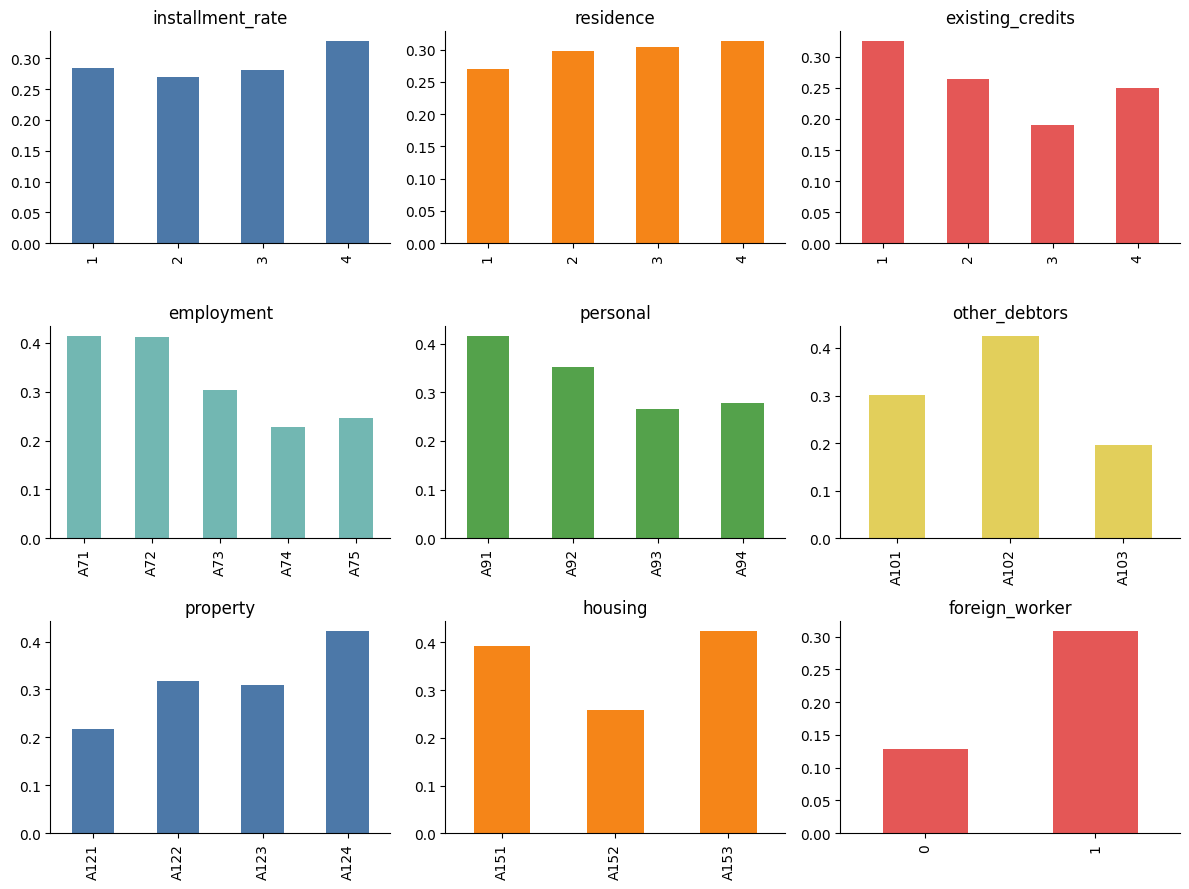

In [ ]:
crosstabplots(train[discrete + categorical + binary], train['default'])
plt.show()

Notably, the default rates exhibit considerable variation based on the status of the existing credits, employment and personal.

## 5. Data Transformation

Similar to last week, we need to transform the dataset before fitting the model. This involves encoding categorical variables, scaling continuous variables, and preparing the data for model training and validation.
We will use dummy encoding (one hot encoding) for categorical variables, standard scaling for continuous variables, and ensure that the target variable is properly formatted for binary classification.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Step 1: Dummy encode categorical and discrete variables on train and valid
train_enc = pd.get_dummies(train, columns=discrete + categorical, drop_first=True, dtype=float)
valid_enc = pd.get_dummies(valid, columns=discrete + categorical, drop_first=True, dtype=float)

# Align validation columns to match training (handles any unseen categories)
valid_enc = valid_enc.reindex(columns=train_enc.columns, fill_value=0)

In [ ]:
# Step 2: Define predictor names (all columns except the response)
variable_names = [col for col in train_enc.columns if col not in response]
print(variable_names)

['duration', 'amount', 'age', 'foreign_worker', 'installment_rate_2', 'installment_rate_3', 'installment_rate_4', 'residence_2', 'residence_3', 'residence_4', 'existing_credits_2', 'existing_credits_3', 'existing_credits_4', 'employment_A72', 'employment_A73', 'employment_A74', 'employment_A75', 'personal_A92', 'personal_A93', 'personal_A94', 'other_debtors_A102', 'other_debtors_A103', 'property_A122', 'property_A123', 'property_A124', 'housing_A152', 'housing_A153']


In [ ]:
# Step 3: Fit scaler on training data only, then apply to both sets
scaler = StandardScaler()
train_enc[continuous] = scaler.fit_transform(train_enc[continuous])
valid_enc[continuous] = scaler.transform(valid_enc[continuous])

In [ ]:
# Step 4: Extract feature matrices and target vectors
X_train = train_enc[variable_names].values
y_train = train_enc['default'].values

X_valid = valid_enc[variable_names].values
y_valid = valid_enc['default'].values

print("X_train shape:", X_train.shape)
print("X_valid shape: ", X_valid.shape)

X_train shape: (791, 27)
X_valid shape:  (198, 27)


### Multicollinearity Check (VIF)

Before fitting the model, it is good practice to check for **multicollinearity**, when two or more predictors are highly correlated with each other. Multicollinearity does not bias predictions but inflates standard errors, making individual coefficient estimates unreliable.

We use the **Variance Inflation Factor (VIF)**:

| VIF | Interpretation |
|-----|---------------|
| 1 | No correlation with other predictors |
| 1 – 5 | Moderate correlation, generally acceptable |
| > 10 | High multicollinearity — consider removing or combining the variable |

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame({
    "Variable": variable_names,
    "VIF": [variance_inflation_factor(X_train, i) for i in range(X_train.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print(vif_df.to_string(index=False))

          Variable       VIF
    foreign_worker 18.789860
      personal_A93  9.585662
      personal_A92  5.900389
    employment_A73  5.795828
installment_rate_4  5.725135
      housing_A152  5.250795
    employment_A75  4.862083
       residence_4  4.483969
     property_A124  3.628469
    employment_A74  3.469827
      housing_A153  3.432830
       residence_2  3.394077
    employment_A72  3.260823
installment_rate_2  2.891206
      personal_A94  2.626366
     property_A123  2.490749
installment_rate_3  2.452060
       residence_3  2.158855
            amount  2.151003
          duration  1.935323
     property_A122  1.890664
existing_credits_2  1.584014
               age  1.391376
other_debtors_A103  1.117191
existing_credits_3  1.109087
other_debtors_A102  1.085830
existing_credits_4  1.032536


**How it actually works:**

For each variable, **VIF** runs a separate regression (OLS) where that variable becomes the dependent variable, and all other predictors become the independent variables.

It then takes the R² from that regression and computes:

```VIF = 1 / (1 - R²)```

What this captures:
That R² tells you how well the other variables can explain/predict that one variable. If it's high, that variable is largely redundant given the others, hence a high VIF.

## 6. Fitting a Logistic Regression Model

The response variable is binary, namely default or non-default. Therefore, it's a natural choice to choose a logistic regression model.

In [ ]:
# Create a DataFrame with the original variable names
df = pd.DataFrame(X_train, columns=variable_names)

# Add a constant (intercept) term
df = sm.add_constant(df)

# Fit the logistic regression model
logit_sm_model = sm.Logit(y_train, df)
result = logit_sm_model.fit()

print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.548550
         Iterations 6
                          Results: Logit
Model:               Logit            Method:           MLE       
Dependent Variable:  y                Pseudo R-squared: 0.103     
Date:                2026-03-09 09:09 AIC:              923.8064  
No. Observations:    791              BIC:              1054.6588 
Df Model:            27               Log-Likelihood:   -433.90   
Df Residuals:        763              LL-Null:          -483.79   
Converged:           1.0000           LLR p-value:      2.8140e-10
No. Iterations:      6.0000           Scale:            1.0000    
------------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------
const              -0.8849   0.8392 -1.0545 0.2917 -2.5297  0.7599
duration            0.4044   0.1124  3.5969 0.0003  0

### Removing High-VIF Variables

If the VIF results show any variable with VIF > 10, we should consider removing it. In this dataset, `foreign_worker` is a candidate — it is a binary variable with very low variance (the vast majority of borrowers are foreign workers), which inflates its VIF.

We refit the model without it and compare using:
- **AIC / BIC** — lower is better; penalises model complexity
- **Log-Likelihood** — higher (less negative) is better; measures goodness of fit
- **Pseudo R²** — higher is better; analogous to R² in linear regression

If the reduced model scores similarly or better, removing the variable is justified.

***PRACTICE: Feel free to experiment with removing other high-VIF variables (if any) or variables that are not statistically significant (p > 0.05) and see how it affects model performance.***

In [ ]:
# Training same model without 'foreign_worker' (the only variable with VIF > 10)
df_no_fw = df.drop(columns=['foreign_worker'])
logit_no_fw = sm.Logit(y_train, df_no_fw)
result_no_fw = logit_no_fw.fit()
print(result_no_fw.summary())


Optimization terminated successfully.
         Current function value: 0.550253
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  791
Model:                          Logit   Df Residuals:                      764
Method:                           MLE   Df Model:                           26
Date:                Mon, 09 Mar 2026   Pseudo R-squ.:                  0.1003
Time:                        09:09:14   Log-Likelihood:                -435.25
converged:                       True   LL-Null:                       -483.79
Covariance Type:            nonrobust   LLR p-value:                 3.922e-10
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.0086      0.607     -0.014      0.989      -1.199       1.181
durat

In [ ]:
# Compare model performance: full model vs model without 'foreign_worker'
compare_df = pd.DataFrame({
    "Metric": ["AIC", "BIC", "Log-Likelihood", "Pseudo R²"],
    "Full Model": [
        round(result.aic, 2),
        round(result.bic, 2),
        round(result.llf, 2),
        round(result.prsquared, 4)
    ],
    "Without unwanted cols <foreign_worker>": [
        round(result_no_fw.aic, 2),
        round(result_no_fw.bic, 2),
        round(result_no_fw.llf, 2),
        round(result_no_fw.prsquared, 4)
    ]
})
print(compare_df.to_string(index=False))

        Metric  Full Model  Without unwanted cols <foreign_worker>
           AIC    923.8100                                924.5000
           BIC   1054.6600                               1050.6800
Log-Likelihood   -433.9000                               -435.2500
     Pseudo R²      0.1031                                  0.1003


**!!! NOTE !!!**

**For tutorial purposes, we will proceed with the full model (including `foreign_worker`) to demonstrate how to interpret the results and compute odds ratios. In practice, you may choose to remove it based on the VIF and model comparison results.**

### Interpreting the Statsmodels Summary

| Column | Meaning |
|--------|---------|
| **coef** | Change in log-odds per unit increase. Positive = higher default probability. |
| **P>\|z\|** | p-value. Variables with p < 0.05 are statistically significant. |
| **[0.025, 0.975]** | 95% confidence interval. If it does not cross zero, the variable is significant. |

**Why statsmodels here?** Unlike `sklearn`, `statsmodels` provides p-values and confidence intervals, making it ideal for understanding *which* variables matter — crucial for credit risk reporting and regulatory explainability.

What insights can be drawn from this output? Which variables are significant predictors of default?

### Odds Ratios

Raw logistic regression coefficients represent changes in **log-odds**, which are hard to interpret intuitively. Exponentiating gives **odds ratios (OR)**:

$$OR = e^{\beta}$$

| OR value | Interpretation |
|----------|---------------|
| OR > 1 | Variable *increases* the odds of default (e.g. OR = 1.5 → 50% higher odds) |
| OR < 1 | Variable *decreases* the odds of default (e.g. OR = 0.7 → 30% lower odds) |
| OR = 1 | No effect on default probability |

Bars in **blue** are statistically significant (p < 0.05); bars in **gray** are not. Error bars show the 95% confidence interval — if they cross the red line (OR = 1), the effect is not significant.

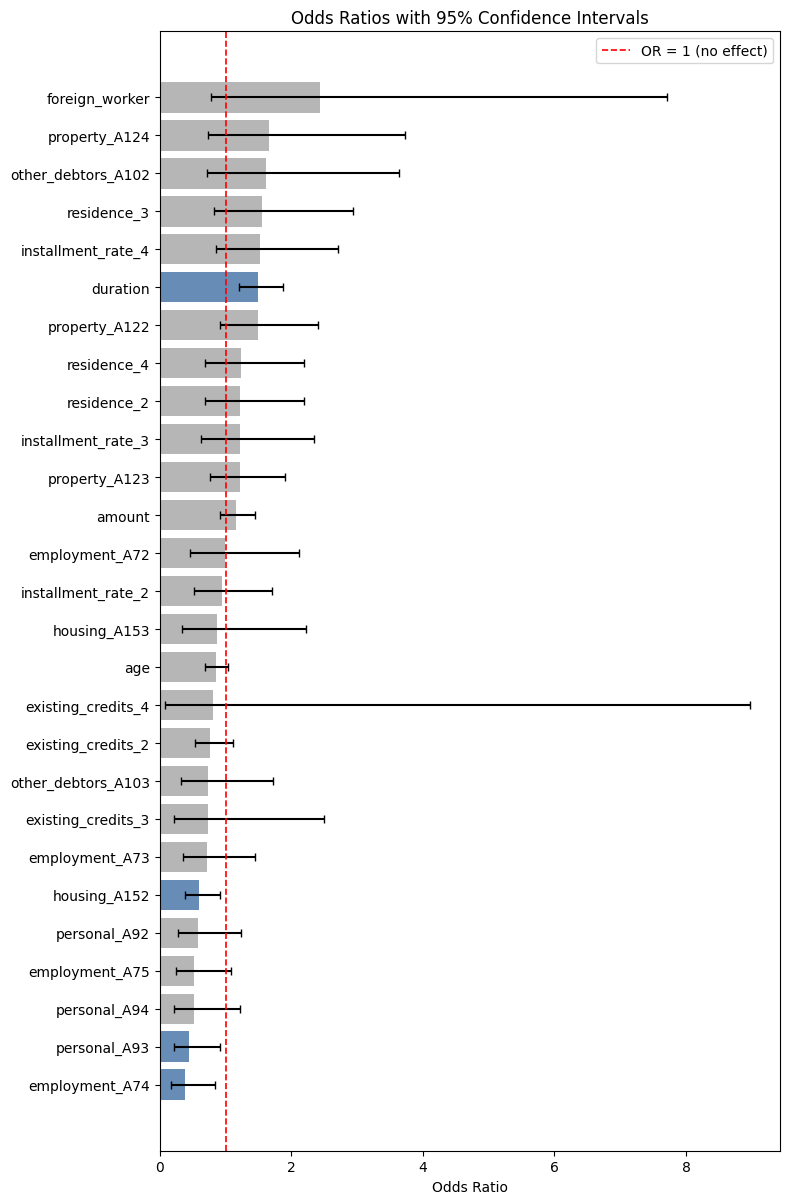

In [34]:
# Extract coefficients, confidence intervals, and p-values
coef_df = pd.DataFrame({
    "Variable": result.model.exog_names[1:],   # skip the constant
    "OR":       np.exp(result.params[1:]),
    "CI_lower": np.exp(result.conf_int().iloc[1:, 0]),
    "CI_upper": np.exp(result.conf_int().iloc[1:, 1]),
    "p_value":  result.pvalues[1:]
}).sort_values("OR", ascending=True).reset_index(drop=True)

bar_colors = [binary_color[0] if p < 0.05 else binary_color[1] for p in coef_df["p_value"]]

fig, ax = plt.subplots(figsize=(8, max(5, len(coef_df) * 0.45)))
ax.barh(coef_df["Variable"], coef_df["OR"], color=bar_colors, alpha=0.85)
ax.errorbar(
    coef_df["OR"], coef_df["Variable"],
    xerr=[coef_df["OR"] - coef_df["CI_lower"],
          coef_df["CI_upper"] - coef_df["OR"]],
    fmt="none", color="black", capsize=3
)
ax.axvline(x=1, color="red", linestyle="--", linewidth=1.2, label="OR = 1 (no effect)")
ax.set_xlabel("Odds Ratio")
ax.set_title("Odds Ratios with 95% Confidence Intervals")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Model Validation

We evaluate the model using the following metrics:

- **Sensitivity (Recall):** The proportion of actual defaults correctly predicted. High sensitivity means fewer missed defaults.
- **Specificity:** The proportion of actual non-defaults correctly predicted. High specificity means fewer good customers wrongly rejected.
- **Precision:** Of all borrowers flagged as high risk, the proportion that actually defaulted.
- **AUC (Area Under the ROC Curve):** Measures the model's overall ability to discriminate between defaulters and non-defaulters across all thresholds. Ranges from 0.5 (random) to 1.0 (perfect).

#### Model Performance on the Training Set (statsmodels)

Let's create a function to evaluate the logistic regression model on the training set and return performance metrics such as accuracy, sensitivity, specificity, precision, and AUC. This function will be reusable for both training and validation sets.

In [35]:
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score

def evaluate_logistic_model(model, X, y, variable_names, dataset_name, thresholds=0.5, model_name="Logistic Regression", add_constant=True):
    """
    Evaluate a logistic regression model on a given dataset and return performance metrics.

    Parameters:
    - model: Trained logistic regression model (statsmodels)
    - X: Feature matrix (numpy array or pandas DataFrame)
    - y: True labels (numpy array or pandas Series)
    - variable_names: List of feature names for X
    - dataset_name: String to identify the dataset (e.g., 'Validation', 'Test', 'Train')
    - model_name: Name of the model for labeling results (default is "Logistic Regression")
    - thresholds: Threshold for classification (default is 0.5)
    - add_constant: Whether to add a constant term to the feature matrix (default is True)

    Returns:
    - results_df: DataFrame containing accuracy, sensitivity, specificity, precision, and AUC
    """
    # Add constant and predict probabilities
    if add_constant:
        X_with_const = sm.add_constant(pd.DataFrame(X, columns=variable_names))
        y_pred = model.predict(X_with_const)
    else:
        X_with_const = pd.DataFrame(X, columns=variable_names)
        y_pred = model.predict_proba(X_with_const)[:, 1]

    # Compute confusion matrix metrics
    tn, fp, fn, tp = confusion_matrix(y, (y_pred > thresholds).astype(int)).ravel()

    # Calculate metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y, (y_pred > thresholds).astype(int), zero_division=0)
    auc = roc_auc_score(y, y_pred)

    # Store results in DataFrame
    results_df = pd.DataFrame({
        "Accuracy": [accuracy],
        "Sensitivity": [sensitivity],
        "Specificity": [specificity],
        "Precision": [precision],
        "AUC": [auc]
    }, index=[f"{model_name} ({dataset_name})"])

    return results_df.round(2)

In [36]:
results_train = evaluate_logistic_model(result, X_train, y_train, variable_names, "Train")
results_train

,Accuracy,Sensitivity,Specificity,Precision,AUC
Logistic Regression (Train),0.73,0.28,0.93,0.63,0.71


In [37]:
results_valid = evaluate_logistic_model(result, X_valid, y_valid, variable_names, "Validation")
results_valid

,Accuracy,Sensitivity,Specificity,Precision,AUC
Logistic Regression (Validation),0.7,0.27,0.88,0.5,0.68


### Precision-Recall Curve

For imbalanced datasets, the **Precision-Recall (PR) curve** is often more informative than the ROC curve.

- The **ROC curve** can appear optimistic on imbalanced data because it accounts for True Negatives, which are abundant when the majority class dominates.
- The **PR curve** focuses solely on the positive class (defaults), showing the trade-off between:
  - **Precision**: Of all borrowers flagged as high risk, what fraction actually defaulted?
  - **Recall**: Of all actual defaults, what fraction did we catch?

The dashed baseline represents a random classifier with precision equal to the proportion of positives (~30%). The further our curve is above this baseline, the better the model.

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, _ = precision_recall_curve(y_valid, y_prob)
avg_precision = average_precision_score(y_valid, y_prob)
baseline = y_valid.mean()

plt.figure(figsize=(7, 5))
plt.plot(recall_vals, precision_vals,
         label=f"Logistic Regression (AP = {avg_precision:.2f})",
         color=colors[0], linewidth=2)
plt.axhline(y=baseline, linestyle="--", color="gray",
            label=f"Random Classifier (AP = {baseline:.2f})")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'y_prob' is not defined

## 8. Business Input & Threshold Selection

So far we used the default threshold of **0.5** to classify borrowers. But is 0.5 the right cut-off for a credit risk problem?

### Cost Asymmetry
Misclassification errors are not equally costly in lending:

| | Actual: No Default | Actual: Default |
|---|---|---|
| **Predicted: No Default** | True Negative ✓ | **False Negative** — bank lends to a defaulter (high cost) |
| **Predicted: Default** | **False Positive** — good customer rejected (lost revenue) | True Positive ✓ |

A **False Negative** (missing a default) is typically far more costly than a **False Positive** (declining a creditworthy customer). This means we often want to **lower the threshold** below 0.5 to flag more potential defaults — accepting more false alarms to avoid missed defaults.

### Why switch to sklearn?
statsmodels is excellent for inference (p-values, coefficients). sklearn offers more flexibility for threshold tuning. We use `penalty=None` to match the unregularised statsmodels model.

(Tau (τ) is simply the Greek letter commonly used in statistics and mathematics to denote a threshold or cut-off value.)

In [ ]:
from sklearn.linear_model import LogisticRegression

# No regularisation (penalty=None) to match the unregularised statsmodels model
logit = LogisticRegression(penalty=None, max_iter=1000)
logit.fit(X_train, y_train)

# Predict probabilities on validation set
y_prob = logit.predict_proba(X_valid)[:, 1]

# Start with the default threshold of 0.5
tau = 0.5
y_pred = (y_prob > tau).astype(int)

print(f"Threshold: {tau}")
print(classification_report(y_valid, y_pred, target_names=["No Default", "Default"]))

Threshold: 0.5
              precision    recall  f1-score   support

  No Default       0.73      0.88      0.80       138
     Default       0.50      0.27      0.35        60

    accuracy                           0.70       198
   macro avg       0.62      0.58      0.58       198
weighted avg       0.66      0.70      0.66       198



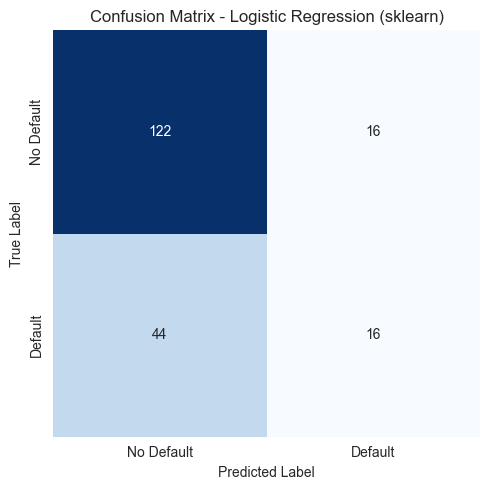

In [ ]:
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(5, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"],
    cbar=False  # remove colorbar
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression (sklearn)")
plt.tight_layout()
plt.show()


Is the model performing well? Why or why not?

### ROC Curve

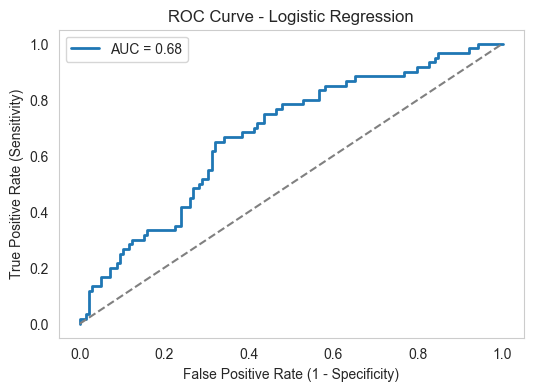

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_valid, y_prob)

# Compute AUC score
auc_score = roc_auc_score(y_valid, y_prob)

# Plot ROC AUC curve
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # Diagonal line for reference
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


### Optimal Threshold

The optimal threshold (tau) is chosen to maximize sensitivity while keeping false positives low. This threshold value is crucial for determining the model's predictive performance.

In [ ]:
fpr, tpr, thresholds = roc_curve(y_valid, y_prob)
optimal_idx = np.argmax(tpr - fpr)   # Youden's J: maximise Sensitivity + Specificity - 1
optimal_tau = thresholds[optimal_idx]
print(f"Optimal threshold (Youden's J): {optimal_tau:.2f}")

Optimal threshold: 0.31


We used the Youden's J Statistic (also known as maximizing Sensitivity - Specificity) to determine the optimal classification threshold. This method selects the threshold that maximizes the difference between the true positive rate (Sensitivity) and the false positive rate (1 - Specificity).

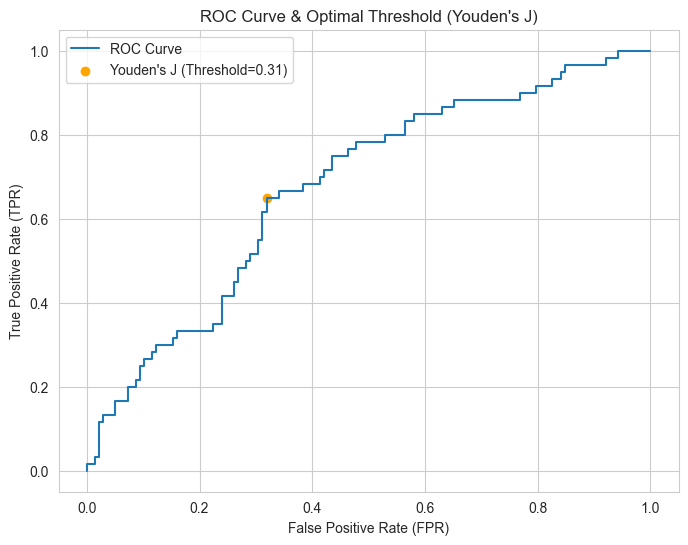

In [ ]:
# Plot ROC Curve with Optimal Threshold (Youden's J)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="ROC Curve")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='orange', label=f"Youden's J (Threshold={optimal_tau:.2f})")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve & Optimal Threshold (Youden's J)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Refit with no regularisation and apply the Youden's J optimal threshold
logit = LogisticRegression(penalty=None, max_iter=1000)
logit.fit(X_train, y_train)

y_prob = logit.predict_proba(X_valid)[:, 1]
y_pred_opt = (y_prob > optimal_tau).astype(int)

print(f"Threshold: {optimal_tau:.2f} (Youden's J)")
print(classification_report(y_valid, y_pred_opt, target_names=["No Default", "Default"]))

              precision    recall  f1-score   support

  No Default       0.81      0.68      0.74       138
     Default       0.46      0.63      0.54        60

    accuracy                           0.67       198
   macro avg       0.64      0.66      0.64       198
weighted avg       0.71      0.67      0.68       198



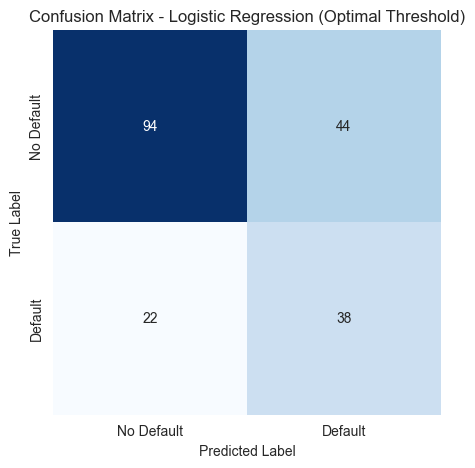

In [ ]:
cm = confusion_matrix(y_valid, y_pred_opt)

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"], cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix — Youden's J Threshold ({optimal_tau:.2f})")
plt.tight_layout()
plt.show()

### Cost-Optimal Threshold

Youden's J treats sensitivity and specificity symmetrically. In credit risk, we can do better by incorporating the **actual cost ratio** between error types.

We define:
- **C_FN** = cost of a False Negative (lending to a defaulter) — set this to the average loss given default
- **C_FP** = cost of a False Positive (rejecting a good customer) — set this to lost interest revenue

At each candidate threshold we compute the **total expected cost** on the validation set:

$$\text{Total Cost} = C_{FN} \times FN + C_{FP} \times FP$$

We then choose the threshold that **minimises** this cost. If C_FN > C_FP (as is typical), the cost-optimal threshold will be **lower** than Youden's J — flagging more borrowers as high risk to avoid costly missed defaults.

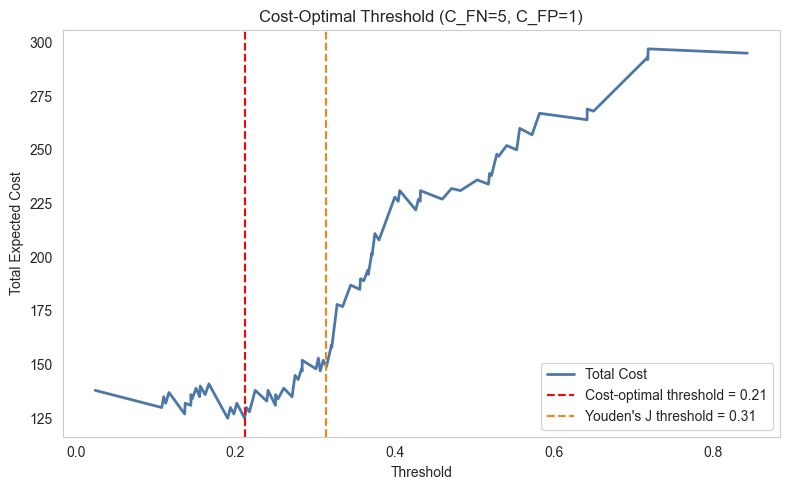

Cost-optimal threshold : 0.21
Youden's J threshold   : 0.31


In [ ]:
# Define the cost ratio — adjust these to reflect real business costs
C_FN = 5   # missing a default is 5x more costly than a false alarm
C_FP = 1

fpr_c, tpr_c, thresholds_c = roc_curve(y_valid, y_prob)
fn_rate = 1 - tpr_c

n_defaults    = y_valid.sum()
n_no_defaults = len(y_valid) - n_defaults

# Total cost at each threshold
total_cost = C_FN * fn_rate * n_defaults + C_FP * fpr_c * n_no_defaults

cost_idx = np.argmin(total_cost)
cost_tau = thresholds_c[cost_idx]

# Plot cost curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds_c, total_cost, color=colors[0], linewidth=2, label="Total Cost")
plt.axvline(x=cost_tau, color="red", linestyle="--",
            label=f"Cost-optimal threshold = {cost_tau:.2f}")
plt.axvline(x=optimal_tau, color=colors[1], linestyle="--",
            label=f"Youden's J threshold = {optimal_tau:.2f}")
plt.xlabel("Threshold")
plt.ylabel("Total Expected Cost")
plt.title(f"Cost-Optimal Threshold (C_FN={C_FN}, C_FP={C_FP})")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cost-optimal threshold : {cost_tau:.2f}")
print(f"Youden's J threshold   : {optimal_tau:.2f}")

=== Cost-Optimal Threshold (tau = 0.21) ===
              precision    recall  f1-score   support

  No Default       0.85      0.42      0.56       138
     Default       0.38      0.83      0.53        60

    accuracy                           0.55       198
   macro avg       0.62      0.63      0.54       198
weighted avg       0.71      0.55      0.55       198



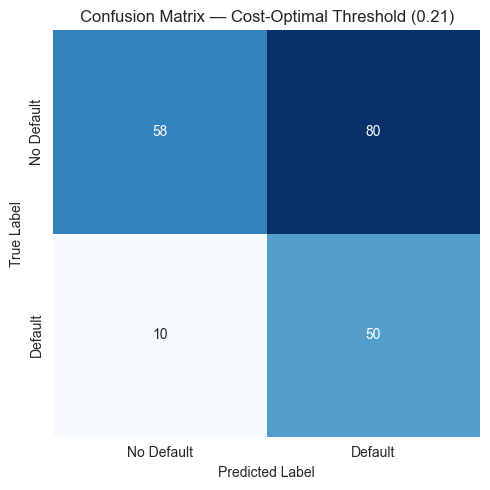

In [ ]:
# Evaluate model at cost-optimal threshold
y_pred_cost = (y_prob > cost_tau).astype(int)

print(f"=== Cost-Optimal Threshold (tau = {cost_tau:.2f}) ===")
print(classification_report(y_valid, y_pred_cost, target_names=["No Default", "Default"]))

# Confusion matrix
cm_cost = confusion_matrix(y_valid, y_pred_cost)
plt.figure(figsize=(5, 5))
sns.heatmap(cm_cost, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Default", "Default"],
            yticklabels=["No Default", "Default"], cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix — Cost-Optimal Threshold ({cost_tau:.2f})")
plt.tight_layout()
plt.show()

**Key insight:** Changing C_FN/C_FP shifts the threshold:
- Higher C_FN → lower threshold → catch more defaults (higher recall) at the cost of more false alarms
- Higher C_FP → higher threshold → fewer false alarms but more missed defaults

In practice, these costs come from the business — e.g. average loan size, recovery rate, and expected interest income — making this a collaborative exercise between the data scientist and the credit risk team.

## 9. Handling Class Imbalance with `class_weight="balanced"`

Our dataset has a 70/30 class imbalance. The model sees roughly twice as many "no default" examples during training, which can bias it toward predicting the majority class.

Setting `class_weight="balanced"` tells sklearn to automatically upweight the minority class (defaults) during training. The weight for each class is:

$$w_c = \frac{n_{\text{samples}}}{n_{\text{classes}} \times n_{c}}$$

This makes the model penalise missed defaults more heavily without changing the data itself. Let us compare the two models side by side.

In [ ]:
# Train a class-weighted logistic regression model
logit_bal = LogisticRegression(penalty=None, class_weight="balanced", max_iter=1000)
logit_bal.fit(X_train, y_train)

y_prob_bal = logit_bal.predict_proba(X_valid)[:, 1]
y_pred_bal = (y_prob_bal > 0.5).astype(int)

# Recompute baseline predictions at tau=0.5 for fair comparison
y_pred_base = (y_prob > 0.5).astype(int)

print("=== Unweighted Model (tau = 0.5) ===")
print(classification_report(y_valid, y_pred_base, target_names=["No Default", "Default"]))

print("=== class_weight='balanced' Model (tau = 0.5) ===")
print(classification_report(y_valid, y_pred_bal, target_names=["No Default", "Default"]))

=== Unweighted Model (tau = 0.5) ===
              precision    recall  f1-score   support

  No Default       0.81      0.68      0.74       138
     Default       0.46      0.63      0.54        60

    accuracy                           0.67       198
   macro avg       0.64      0.66      0.64       198
weighted avg       0.71      0.67      0.68       198

=== class_weight='balanced' Model (tau = 0.5) ===
              precision    recall  f1-score   support

  No Default       0.81      0.62      0.70       138
     Default       0.43      0.67      0.53        60

    accuracy                           0.64       198
   macro avg       0.62      0.64      0.62       198
weighted avg       0.70      0.64      0.65       198



**Discussion:**
- The balanced model typically improves **recall for defaults** (fewer missed defaults) at the expense of slightly lower precision.
- This trade-off aligns with the business objective: it is cheaper to flag a few extra good customers than to miss actual defaults.
- `class_weight="balanced"` is a quick first step.

## 10. Oversampling with SMOTE

`class_weight="balanced"` reweights the loss function but trains on the same data. **SMOTE (Synthetic Minority Over-sampling Technique)** takes a different approach — it *generates new synthetic minority class examples* to balance the training set before fitting.

### How SMOTE works
1. For each minority class sample (a defaulter), find its k nearest neighbours in feature space.
2. Randomly select one of those neighbours.
3. Create a new synthetic point somewhere along the line connecting the two.

This is more informative than simple duplication (which just repeats the same points) because it interpolates in feature space to create plausible new examples.

> **Important:** SMOTE must only be applied to the **training set**. The validation set must remain untouched — otherwise we are evaluating on artificial data.

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training set only
smote = SMOTE(random_state=21)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Original training set — No Default: {(y_train == 0).sum()}, Default: {(y_train == 1).sum()}")
print(f"After SMOTE          — No Default: {(y_train_sm == 0).sum()}, Default: {(y_train_sm == 1).sum()}")

Original training set — No Default: 553, Default: 238
After SMOTE          — No Default: 553, Default: 553


In [ ]:
# Fit logistic regression on SMOTE-balanced training data
logit_sm = LogisticRegression(penalty=None, max_iter=1000)
logit_sm.fit(X_train_sm, y_train_sm)

# Evaluate on the original (untouched) validation set
y_prob_sm = logit_sm.predict_proba(X_valid)[:, 1]
y_pred_sm = (y_prob_sm > 0.5).astype(int)

print("=== Original Model (tau = 0.5) ===")
print(classification_report(y_valid, y_pred_base, target_names=["No Default", "Default"]))

print("=== SMOTE Model (tau = 0.5) ===")
print(classification_report(y_valid, y_pred_sm, target_names=["No Default", "Default"]))

=== Original Model (tau = 0.5) ===
              precision    recall  f1-score   support

  No Default       0.81      0.68      0.74       138
     Default       0.46      0.63      0.54        60

    accuracy                           0.67       198
   macro avg       0.64      0.66      0.64       198
weighted avg       0.71      0.67      0.68       198

=== SMOTE Model (tau = 0.5) ===
              precision    recall  f1-score   support

  No Default       0.77      0.59      0.67       138
     Default       0.39      0.60      0.47        60

    accuracy                           0.60       198
   macro avg       0.58      0.60      0.57       198
weighted avg       0.66      0.60      0.61       198



**Discussion:**
- SMOTE typically boosts **recall for defaults** similar to `class_weight="balanced"`, but by enriching the training distribution rather than adjusting the loss.
- SMOTE can sometimes lead to **overfitting** if the synthetic points fall in unrealistic regions — always validate on real held-out data.
- For tabular data with mixed variable types (continuous + categorical dummies), SMOTE operates on the transformed feature space, which is acceptable here since all features are numeric after encoding.

### Summary: Imbalance Handling Strategies

| Method | What it does | Pros | Cons |
|--------|-------------|------|------|
| Default (tau=0.5) | No adjustment | Simple, interpretable | Biased toward majority class |
| Lower threshold | Classify more as default | No retraining needed | Increases false positives |
| `class_weight="balanced"` | Upweights minority in loss | Fast, no data change | Approximate cost weighting |
| Cost-optimal threshold | Minimises expected financial cost | Business-aligned | Requires cost estimates |
| SMOTE | Generates synthetic minority samples | Richer training data | Risk of overfitting |